#  Predict canopy height using DEA satellite data


## Import libraries

In [1]:
import odc.stac
import pystac_client
import xarray as xr
import numpy as np
import rioxarray as rxr
from joblib import load
import matplotlib.pyplot as plt

from odc.geo import BoundingBox
from odc.geo.xr import assign_crs
from odc.stac import stac_load

import shap
import lightgbm as lgb
from dea_tools.classification import predict_xr

from odc.algo import geomedian_with_mads
from dea_tools.dask import create_local_dask_cluster
from dea_tools.plotting import display_map
from dea_tools.bandindices import calculate_indices

from dualpol_indices import dualpol_indices
from speckle_filters import apply_lee_filter

## Start dask client

In [2]:
client = create_local_dask_cluster(return_client=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 15,Total memory: 117.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39605,Workers: 1
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,Total threads: 15
Started: Just now,Total memory: 117.21 GiB
Comm: tcp://127.0.0.1:34551,Total threads: 15
Dashboard: /user/chad.burton@ga.gov.au/proxy/33365/status,Memory: 117.21 GiB
Nanny: tcp://127.0.0.1:40833,


## Analysis Parameters

In [3]:
#renamrk
# central_lat, central_lon = -34.9931, 143.5384
# buffer = 0.1
# name='renmark'

#titree
central_lat, central_lon = -37.5962, 140.5354
buffer = 0.1
name='mtgambier'

#titree
# central_lat, central_lon =  -22.0447, 133.3943
# buffer = 0.1
# name='titree'

# Set a start and end date
start_date = "2025-01-01"
end_date = "2025-08-31"

# data loading params
crs="EPSG:3577"
resolution=20
measurements=[
 'nbart_red',
 'nbart_blue',
 'nbart_green',
 'nbart_nir_1',
 'nbart_nir_2',
 'nbart_swir_2',
 'nbart_swir_3',
 'nbart_red_edge_1',
 'nbart_red_edge_2',
 'nbart_red_edge_3',
]

masking_band = 'oa_s2cloudless_mask'

In [4]:
# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

display_map(x=longitude, y=latitude)

## Open canopy height model

Already processed this in another notebook

In [5]:
chm_model = load(f'test_chm_model.joblib')

### Load S2 data and calculate geomedian

In [6]:
bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

#search catalog
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

query = catalog.search(
    bbox=bbox,
    collections=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
    datetime=f"{start_date}/{end_date}"
)

items = list(query.items())

ds = odc.stac.load(
    items,
    bands=measurements+[masking_band],
    crs=crs,
    resolution=resolution,
    groupby="solar_day",
    bbox=bbox,
    chunks={},
)

clear = xr.where(ds['oa_s2cloudless_mask'] == 1, True, False)
ds = ds.drop_vars(masking_band).where(clear)

s2_gm = geomedian_with_mads(
    ds,
    reshape_strategy='yxbt', #'yxbt' if data is larger than RAM
    compute_mads=True # True if you want triple MADs
)

# bring into memory
s2_gm = assign_crs(s2_gm.load(), crs=crs)
s2_gm = s2_gm.drop_vars('count')

# add veg indices
s2_gm = calculate_indices(s2_gm,index=['EVI', 'kNDVI'],
                          drop=False,
                          collection='ga_s2_3'
                         )

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


## Add Sentinel 1

In [7]:
dev_stac_catalog = pystac_client.Client.open("https://explorer.dev.dea.ga.gov.au/stac")

s1_items = dev_stac_catalog.search(
    bbox=bbox, collections=["ga_s1_nrb_iw_vv_vh_0"], datetime=f"{start_date}/{end_date}"
)

s1_items = list(s1_items.items())

ds_s1 = odc.stac.load(
    s1_items,
    bands=["VV_gamma0", "VH_gamma0", "mask"],
    like=s2_gm.odc.geobox,  # match boundary of gm
    groupby="solar_day",
    chunks={},
)

ds_s1 = ds_s1.rename({"VV_gamma0": "VV", "VH_gamma0": "VH"})

# lee filtering
ds_s1["VV"] = apply_lee_filter(ds_s1["VV"], size=4)
ds_s1["VH"] = apply_lee_filter(ds_s1["VH"], size=4)

valid_mask = xr.where(ds_s1.mask > 0, False, True)
ds_s1 = ds_s1.where(valid_mask).drop_vars("mask")

# calculate Radar veg index
rvi = dualpol_indices(ds_s1, index=["RVI"], drop=True)

# Create temporal summary stats on S1
def dB_scale(data):
    """Scales a xarray.DataArray with linear DN to a dB scale."""
    # Explicitly set negative data to nan to avoid log of negative number
    negative_free_data = data.where(data >= 0, np.nan)
    return 10 * np.log10(negative_free_data)

# Scale to plot data in decibels
ds_s1["VH"] = dB_scale(ds_s1.VH)
ds_s1["VV"] = dB_scale(ds_s1.VV)
ds_s1["VV-VH"] = dB_scale(ds_s1.VV - ds_s1.VH)

ds_s1 = ds_s1.where(valid_mask)

# take temporal stats
ds_s1_mean = ds_s1.mean("time")
rvi_mean = rvi.median("time")

ds_s1_mean = ds_s1_mean.rename(
    {"VV": "VV_mean", "VH": "VH_mean", "VV-VH": "VV-VH_mean"}
)

# ----combine data-----------------
combined = xr.merge([s2_gm, ds_s1_mean, rvi_mean], compat="override").compute()

Dropping bands ['VV', 'VH']


### Predict canopy height

In [8]:
y_pred_xr = predict_xr(chm_model, combined).compute()

predicting...


/env/lib/python3.10/site-packages/distributed/client.py:3361: UserWarning: Sending large graph of size 80.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


### Create a water mask

In [9]:
s2_gm = calculate_indices(s2_gm, index='NDWI', collection='ga_s2_3')
water_mask = ~(s2_gm['NDWI']>0)

# Remove any negative values
y_pred_xr['Predictions'] = xr.where(y_pred_xr['Predictions']<0, 0, y_pred_xr['Predictions'])

### Plot

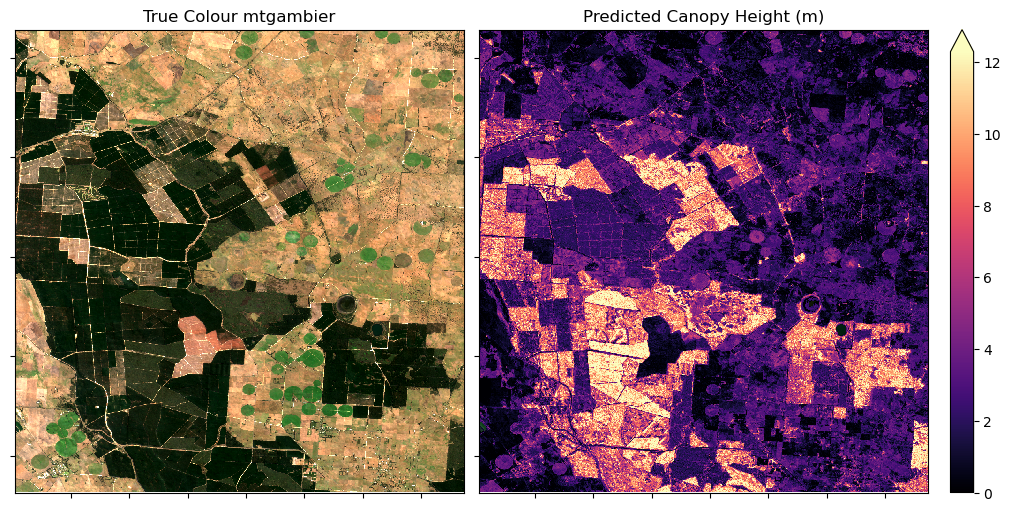

In [14]:
fig,ax=plt.subplots(1,2, figsize=(10,5), sharey=True, layout='constrained')

s2_gm[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(ax=ax[0], robust=True, add_labels=False)

s2_gm[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(ax=ax[1], robust=True, add_labels=False)
y_pred_xr['Predictions'].where(water_mask).plot.imshow(ax=ax[1], robust=True, cmap='magma', add_labels=False)
ax[0].set_title(f'True Colour {name}')
ax[1].set_title('Predicted Canopy Height (m)')
ax[0].set_yticklabels([])
ax[0].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_xticklabels([]);
plt.savefig(f"results/predicted_canopyheight_{name}.png", dpi=300, bbox_inches="tight")

## Compare with existing CSIRO product

Which is built off Landsat geomedians and fractional cover

In [11]:
p='../../data/veg_height/data/LS_2021_100m_Oz_3577_TreeHeight_RFM_v3DEA_Mskd.tif'
ch = rxr.open_rasterio(p, chunks=dict(x=1000, y=1000)).squeeze().drop_vars('band')
ch = assign_crs(ch, crs='EPSG:3577')
ch = ch.where(ch<100)
ch['nodata'] = np.nan

#clip to same region
poly = s2_gm.odc.geobox.boundingbox.boundary().convex_hull
ch = ch.odc.crop(poly)
ch.load()

<xarray.DataArray (y: 233, x: 193)> Size: 180kB
array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [13.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., 28., 35., 23.],
       [ 0.,  0.,  0., ..., 18., 34., 23.],
       [ 0.,  0.,  0., ..., 35., 35., 35.]], dtype=float32)
Coordinates:
  * x            (x) float64 2kB 7.476e+05 7.478e+05 ... 7.668e+05 7.668e+05
  * y            (y) float64 2kB -4.124e+06 -4.124e+06 ... -4.147e+06 -4.147e+06
    spatial_ref  int32 4B 3577
    nodata       float64 8B nan
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

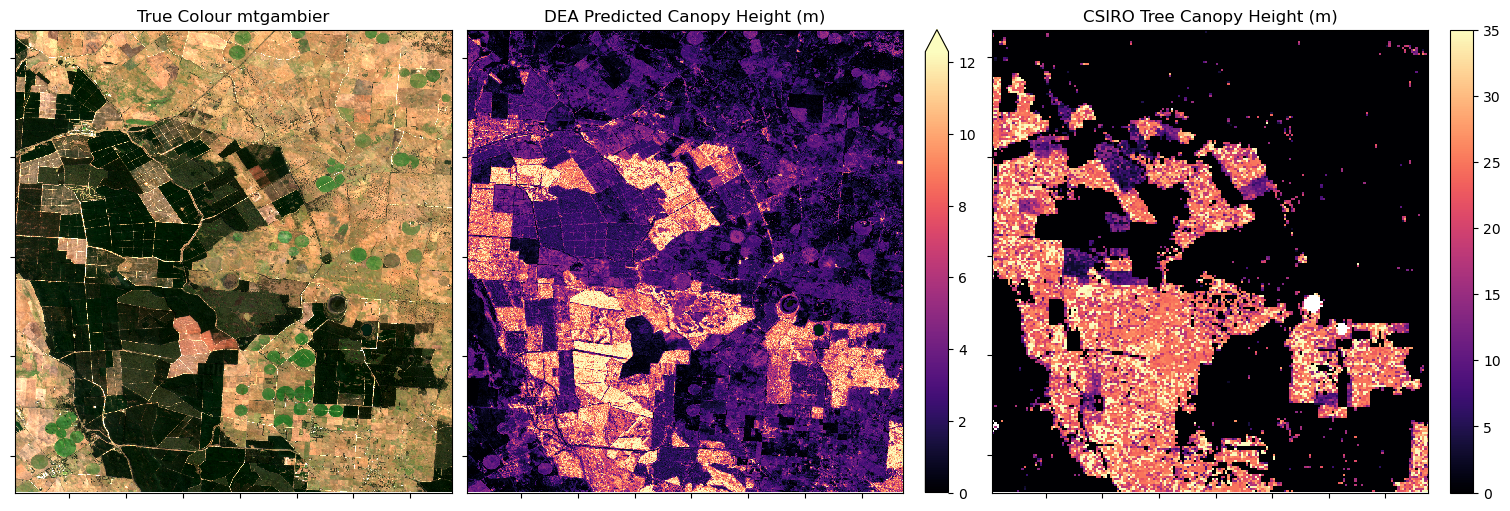

In [12]:
fig,ax=plt.subplots(1,3, figsize=(15,5), layout='constrained')

s2_gm[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(ax=ax[0], robust=True, add_labels=False)
s2_gm[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(ax=ax[1], robust=True, add_labels=False)
y_pred_xr['Predictions'].where(water_mask).plot.imshow(ax=ax[1], robust=True, cmap='magma', add_labels=False)
ch.plot.imshow(ax=ax[2], robust=True, cmap='magma', add_labels=False)

ax[0].set_title(f'True Colour {name}')
ax[1].set_title('DEA Predicted Canopy Height (m)')
ax[2].set_title('CSIRO Tree Canopy Height (m)')
ax[0].set_yticklabels([])
ax[0].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_xticklabels([]);
ax[2].set_yticklabels([])
ax[2].set_xticklabels([]);
plt.savefig(f"results/predicted_canopyheight_CSIRO_{name}.png", dpi=300, bbox_inches="tight")

## Interactive plot

In [13]:
y_pred_xr['Predictions'].where(water_mask).odc.explore(
            tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr = 'Esri',
            name = 'Esri Satellite',
            cmap='magma',
            robust=True
)